# 05 Power spectrum and depth to source

For an ensemble of sources at depth h the power spectrum of the field
falls as exp(-2 h |k|) (Spector and Grant 1970; Blakely 11.3). On a plot of
ln P against k (rad/m) a straight segment of slope s gives

    h = -s / 2

With k in cycles/km the depth in km is -s / (4 pi). Deep sources control
the low wavenumbers, shallow ones the high, so a real spectrum is read as
two or three straight segments. The depth is to the top of a statistical
ensemble, not to any one body, and the segments have to be picked by eye.
Grid padding and edge treatment affect the lowest wavenumbers most.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from potfield import read_grid, write_grid, filters, transforms, spectrum, display

DATA = "../data"
OUT = "../outputs"
INC, DEC = -62.4, 7.5   # IGRF inclination, declination (deg) for the Frome area at 2015.0
plt.rcParams["figure.dpi"] = 90

## Check on a point mass

The spectrum of a point mass at depth z0 is exactly exp(-2 k z0), so any
band should return z0.

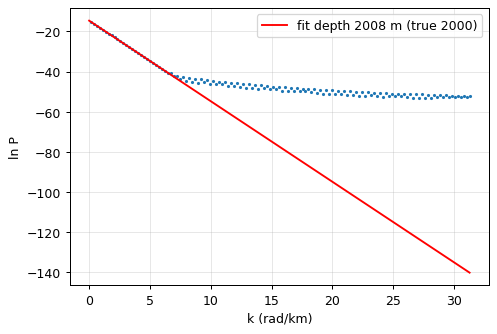

In [2]:
from potfield.synthetic import point_mass_grid
pm, _ = point_mass_grid(256, 256, dx=100, z0=2000)
s = spectrum.radial_power_spectrum(pm)
fit = spectrum.depth_from_wavelengths(s, long_wavelength=6000, short_wavelength=2000)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(s["k"] * 1e3, s["log_power"], ".", ms=3)
kk = np.linspace(0, s["k"].max(), 50)
ax.plot(kk * 1e3, fit["intercept"] + fit["slope"] * kk, "r", label=f"fit depth {fit['depth']:.0f} m (true 2000)")
ax.set_xlabel("k (rad/km)"); ax.set_ylabel("ln P"); ax.legend(); ax.grid(alpha=0.3)

## Frome TMI

Text(0.5, 0, 'wavelength (km)')

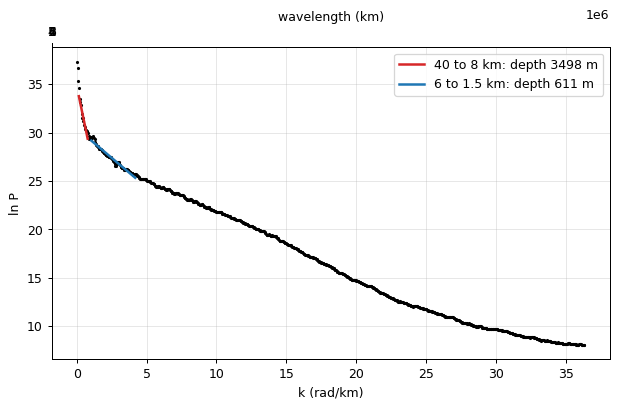

In [3]:
g = read_grid(f"{DATA}/frome_tmi.ers", epsg=28354, units="nT")
rtp = transforms.reduce_to_pole(g, INC, DEC)
s = spectrum.radial_power_spectrum(rtp)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(s["k"] * 1e3, s["log_power"], ".", ms=3, color="k")
for (long_wl, short_wl, colour) in ((40000, 8000, "tab:red"), (6000, 1500, "tab:blue")):
    f = spectrum.depth_from_wavelengths(s, long_wl, short_wl)
    kk = np.array([2 * np.pi / long_wl, 2 * np.pi / short_wl])
    ax.plot(kk * 1e3, f["intercept"] + f["slope"] * kk, color=colour, lw=2,
            label=f"{long_wl/1e3:g} to {short_wl/1e3:g} km: depth {f['depth']:.0f} m")
ax.set_xlabel("k (rad/km)"); ax.set_ylabel("ln P"); ax.legend(); ax.grid(alpha=0.3)
sec = ax.secondary_xaxis("top", functions=(lambda k: 2 * np.pi / np.maximum(k, 1e-6), lambda w: 2 * np.pi / np.maximum(w, 1e-6)))
sec.set_xlabel("wavelength (km)")

Try other bands. The break between segments is where the slope changes;
the deepest segment is at the far left and is the least reliable because
it has the fewest spectral samples and is most affected by the grid size.